<h2>Step 0 - Housekeeping</h2>

In [17]:
# Installs
!pip install plotly pandas numpy scikit-learn

You should consider upgrading via the '/Users/sanjanaalluri/venv/bin/python3 -m pip install --upgrade pip' command.


In [18]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.cluster import DBSCAN
import os

In [19]:
# Load data
csv_path = os.path.join(os.getcwd(), 'prostate_data', 'Prostate_Glycans_pca_median_standardized_first3PC.csv')
df = pd.read_csv(csv_path)

points = df[['PC1', 'PC2', 'PC3']].values
print(f"Loaded {len(points)} points")
print(df.head())

Loaded 152 points
  Category                     Sample_Name       PC1       PC2       PC3
0   Conroy  Conroy__Figure 1__Figure1_1079  7.114706  3.337074  2.057330
1   Conroy  Conroy__Figure 1__Figure1_1257  6.303761  2.795595  1.396539
2   Conroy  Conroy__Figure 1__Figure1_1282  6.643572  3.110815  1.576983
3   Conroy  Conroy__Figure 1__Figure1_1419  6.014139  2.736927  1.210664
4   Conroy  Conroy__Figure 1__Figure1_1688  6.553433  1.233908  4.127674


In [20]:
# General helper to visualize point cloud
def plot_cloud(points, colors=None, title='Point Cloud', size=6):
    fig = go.Figure(data=[go.Scatter3d(
        x=points[:, 0], y=points[:, 1], z=points[:, 2],
        mode='markers',
        marker=dict(
            size=size,
            color=colors if colors is not None else points[:, 2],
            colorscale='Viridis',
            opacity=0.9
        )
    )])
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3',
            bgcolor='white',
            xaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
            yaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
            zaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
        ),
        paper_bgcolor='white',
        font=dict(color='black'),
        margin=dict(l=0, r=0, t=40, b=0)
    )
    fig.show()

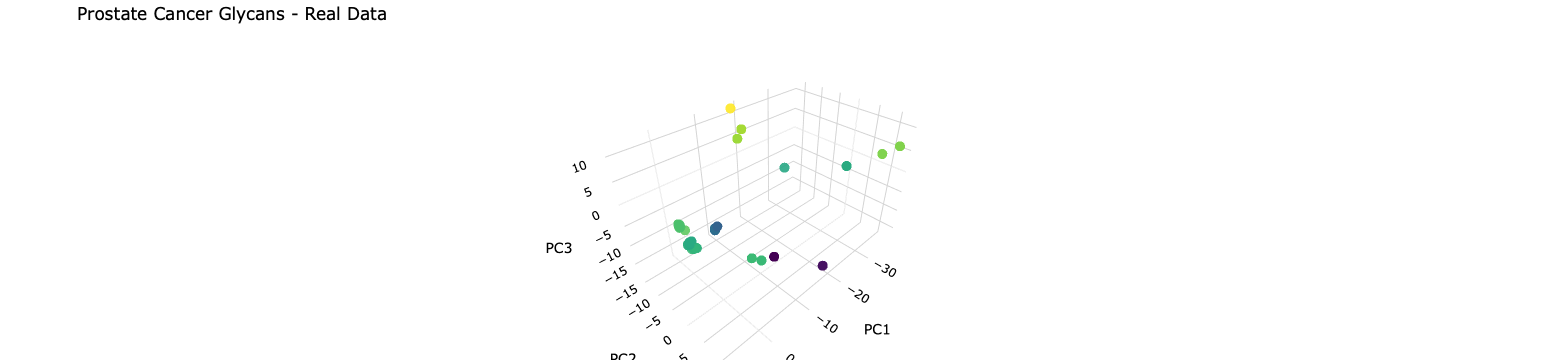

In [21]:
# Plot real data
plot_cloud(points, title='Prostate Cancer Glycans - Real Data')

<h2>Step 1 - Augmentation</h1>

In [6]:
def jitter_augment(points, n_copies=5, jitter_scale=0.5):
    augmented = [points]  # start with real data
    for _ in range(n_copies):
        noise = np.random.normal(0, jitter_scale, points.shape)
        augmented.append(points + noise)
    return np.vstack(augmented)

synthetic_points = jitter_augment(points, n_copies=5, jitter_scale=0.5)
print(f"Original: {len(points)} points")
print(f"After augmentation: {len(synthetic_points)} points")

Original: 152 points
After augmentation: 912 points


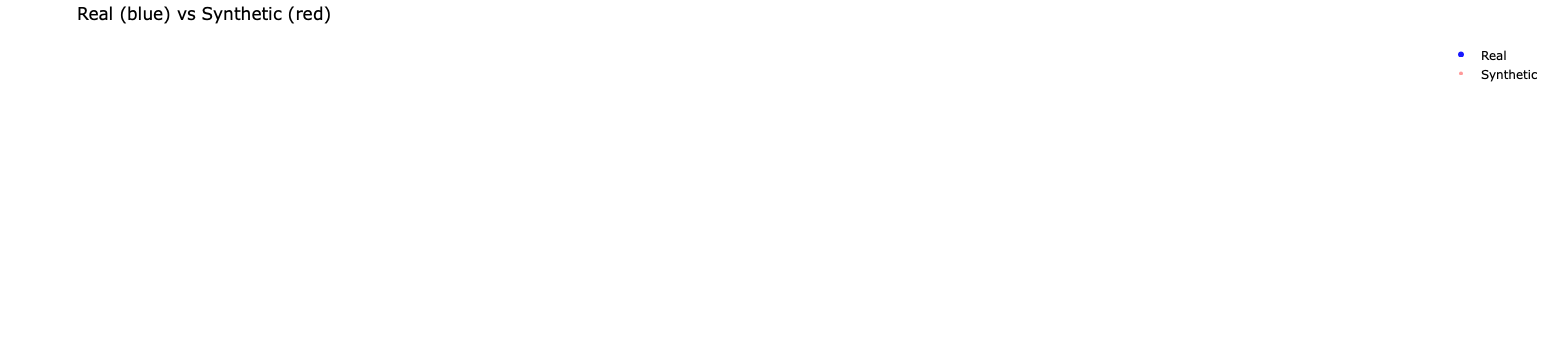

In [7]:
# Visualize augmeted data
real = points
synthetic = synthetic_points[len(points):]  # just the synthetic, not the real

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=real[:, 0], y=real[:, 1], z=real[:, 2],
    mode='markers',
    name='Real',
    marker=dict(size=6, color='blue', opacity=0.9)
))

fig.add_trace(go.Scatter3d(
    x=synthetic[:, 0], y=synthetic[:, 1], z=synthetic[:, 2],
    mode='markers',
    name='Synthetic',
    marker=dict(size=4, color='red', opacity=0.4)
))

fig.update_layout(
    title='Real (blue) vs Synthetic (red)',
    scene=dict(
        xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3',
        bgcolor='white',
        xaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
        yaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
        zaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
    ),
    paper_bgcolor='white',
    font=dict(color='black'),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

<h2>Step 2 - DBSCAN on Real Prostate Data</h2>

In [8]:
from sklearn.cluster import DBSCAN

# dbscan = DBSCAN(eps=3.0, min_samples=3) # too specific
# dbscan = DBSCAN(eps=5.0, min_samples=3) # better but a couple questionable clusters
dbscan = DBSCAN(eps=10.0, min_samples=3)
labels = dbscan.fit_predict(points)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Clusters found: {n_clusters}")
print(f"Outliers found: {n_outliers}")
print(f"Label breakdown: {dict(zip(*np.unique(labels, return_counts=True)))}")

Clusters found: 5
Outliers found: 3
Label breakdown: {np.int64(-1): np.int64(3), np.int64(0): np.int64(117), np.int64(1): np.int64(10), np.int64(2): np.int64(4), np.int64(3): np.int64(9), np.int64(4): np.int64(9)}


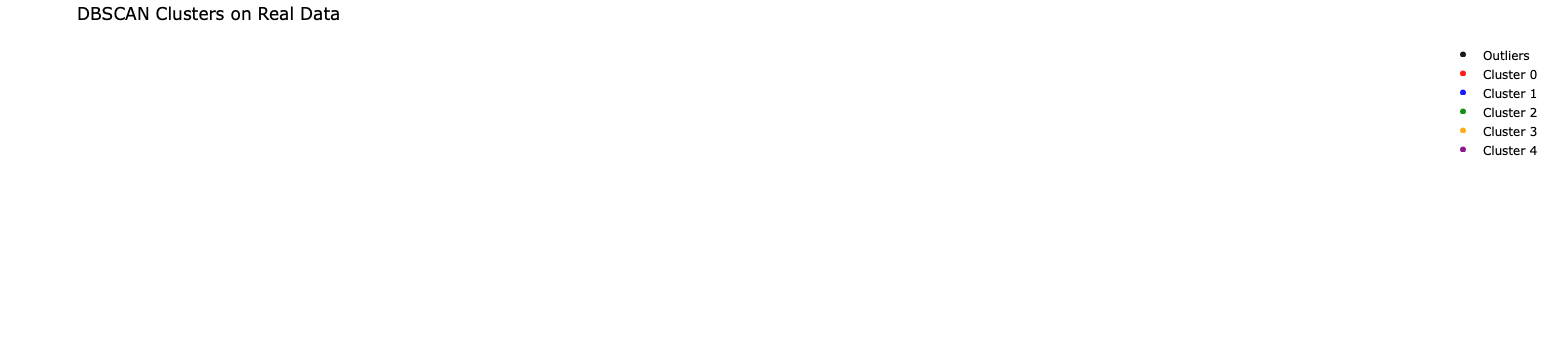

In [9]:
# Visualize DBSCAN clusters
fig = go.Figure()

colors = ['red', 'blue', 'green', 'orange', 'purple', 'pink', 'cyan', 'yellow']

for label in sorted(set(labels)):
    mask = labels == label
    name = f'Cluster {label}' if label != -1 else 'Outliers'
    color = 'black' if label == -1 else colors[label % len(colors)]
    fig.add_trace(go.Scatter3d(
        x=points[mask, 0], y=points[mask, 1], z=points[mask, 2],
        mode='markers',
        name=name,
        marker=dict(size=6, color=color, opacity=0.9)
    ))

fig.update_layout(
    title='DBSCAN Clusters on Real Data',
    scene=dict(
        xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3',
        bgcolor='white',
        xaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
        yaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
        zaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
    ),
    paper_bgcolor='white',
    font=dict(color='black'),
    margin=dict(l=0, r=0, t=40, b=0)
)

fig.show()

In [10]:
# Check for duplicate coordinates
print(f"Total points: {len(points)}")
print(f"Unique points: {len(np.unique(points, axis=0))}")

# Show which points are outliers
outlier_mask = labels == -1
outlier_points = points[outlier_mask]
print(f"\nOutlier coordinates:")
print(outlier_points)

Total points: 152
Unique points: 60

Outlier coordinates:
[[-19.45455752   8.93241824 -16.24190147]
 [-19.45455752   8.93241824 -16.24190147]
 [-23.13799259  -6.00334072  -0.24224151]]


In [11]:
# Recorded DBSCAN results
for label in sorted(set(labels)):
    mask = labels == label
    cluster_points = points[mask]
    if label == -1:
        print(f"Outliers: {mask.sum()} points")
    else:
        centroid = cluster_points.mean(axis=0)
        print(f"Cluster {label}: {mask.sum()} points | centroid: PC1={centroid[0]:.2f}, PC2={centroid[1]:.2f}, PC3={centroid[2]:.2f}")

Outliers: 3 points
Cluster 0: 117 points | centroid: PC1=5.52, PC2=0.98, PC3=0.63
Cluster 1: 10 points | centroid: PC1=-5.32, PC2=-7.87, PC3=-7.64
Cluster 2: 4 points | centroid: PC1=-14.98, PC2=-0.93, PC3=-17.31
Cluster 3: 9 points | centroid: PC1=-35.00, PC2=8.67, PC3=3.94
Cluster 4: 9 points | centroid: PC1=-17.24, PC2=-13.59, PC3=7.69


In [12]:
# Extract clusters A and B
A = points[labels == 0]  # large main cluster
B = points[labels == 1]  # satellite cluster

print(f"Cluster A: {len(A)} points")
print(f"Cluster B: {len(B)} points")

Cluster A: 117 points
Cluster B: 10 points


In [13]:
# Install metric libraries
!pip install scipy

You should consider upgrading via the '/Users/sanjanaalluri/venv/bin/python3 -m pip install --upgrade pip' command.


In [14]:
# Define all 4 metrics
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
from sklearn.metrics import silhouette_score

def chamfer_distance(A, B):
    dists_AB = cdist(A, B).min(axis=1).mean()
    dists_BA = cdist(B, A).min(axis=1).mean()
    return dists_AB + dists_BA

def hausdorff_distance(A, B):
    dists_AB = cdist(A, B).min(axis=1).max()
    dists_BA = cdist(B, A).min(axis=1).max()
    return max(dists_AB, dists_BA)

def wasserstein_distance_3d(A, B):
    # compute per-dimension and average
    return np.mean([wasserstein_distance(A[:, i], B[:, i]) for i in range(3)])

def silhouette(A, B):
    combined = np.vstack([A, B])
    labels = np.array([0]*len(A) + [1]*len(B))
    return silhouette_score(combined, labels)

# Test all metrics at baseline
print(f"Chamfer:     {chamfer_distance(A, B):.4f}")
print(f"Hausdorff:   {hausdorff_distance(A, B):.4f}")
print(f"Wasserstein: {wasserstein_distance_3d(A, B):.4f}")
print(f"Silhouette:  {silhouette(A, B):.4f}")

Chamfer:     29.8542
Hausdorff:   22.4414
Wasserstein: 9.3193
Silhouette:  0.8596


<h2>Step 3 - Parameter Sweep on Real Prostate Data</h2>
<h3>Gradients: Translation and Rotation</h3>

In [15]:
from scipy.spatial.transform import Rotation

def translate_cluster(B, direction, step_size, n_steps):
    direction = direction / np.linalg.norm(direction)
    versions = []
    for i in range(n_steps + 1):
        versions.append(B + direction * step_size * i)
    return versions

def rotate_cluster(B, axis, angle_deg, n_steps):
    centroid = B.mean(axis=0)
    versions = [B]
    for i in range(1, n_steps + 1):
        r = Rotation.from_rotvec(np.radians(angle_deg * i) * axis)
        rotated = r.apply(B - centroid) + centroid
        versions.append(rotated)
    return versions

def compute_metrics(A, B):
    return {
        'chamfer': chamfer_distance(A, B),
        'hausdorff': hausdorff_distance(A, B),
        'wasserstein': wasserstein_distance_3d(A, B),
        'silhouette': silhouette(A, B)
    }

# --- Gradient 1: Translation ---
translation_steps = translate_cluster(B, direction=np.array([1, 0, 0]), step_size=5, n_steps=5)
translation_results = [compute_metrics(A, B_step) for B_step in translation_steps]

# --- Gradient 2: Rotation ---
rotation_steps = rotate_cluster(B, axis=np.array([0, 0, 1]), angle_deg=45, n_steps=5)
rotation_results = [compute_metrics(A, B_step) for B_step in rotation_steps]

print("Translation results:")
for i, r in enumerate(translation_results):
    print(f"  Step {i}: {r}")

print("\nRotation results:")
for i, r in enumerate(rotation_results):
    print(f"  Step {i}: {r}")

Translation results:
  Step 0: {'chamfer': np.float64(29.854187286830772), 'hausdorff': np.float64(22.441396906159238), 'wasserstein': np.float64(9.319270548478533), 'silhouette': 0.8595983521128301}
  Step 1: {'chamfer': np.float64(24.187978822080993), 'hausdorff': np.float64(21.683057919429523), 'wasserstein': np.float64(7.652603881811864), 'silhouette': 0.8331864887560864}
  Step 2: {'chamfer': np.float64(21.925442554616243), 'hausdorff': np.float64(22.06113565469596), 'wasserstein': np.float64(6.048887041560033), 'silhouette': 0.8167871362373077}
  Step 3: {'chamfer': np.float64(24.039041663305902), 'hausdorff': np.float64(23.520893095553564), 'wasserstein': np.float64(7.098549535013293), 'silhouette': 0.8260588876586168}
  Step 4: {'chamfer': np.float64(29.419680171706673), 'hausdorff': np.float64(25.879936585123644), 'wasserstein': np.float64(8.76521620167996), 'silhouette': 0.8517461085209411}
  Step 5: {'chamfer': np.float64(36.64134202044244), 'hausdorff': np.float64(28.903990

In [24]:
# Original plot for reference
plot_cloud(points, title='Prostate Cancer Glycans - Real Data')

# Make visual sweep steps
def plot_sweep_steps(A, steps, title_prefix, color_A='blue', color_B='red'):
    for i, B_step in enumerate(steps):
        fig = go.Figure()
        
        fig.add_trace(go.Scatter3d(
            x=A[:, 0], y=A[:, 1], z=A[:, 2],
            mode='markers', name='Cluster A',
            marker=dict(size=5, color=color_A, opacity=0.9)
        ))
        fig.add_trace(go.Scatter3d(
            x=B_step[:, 0], y=B_step[:, 1], z=B_step[:, 2],
            mode='markers', name='Cluster B',
            marker=dict(size=5, color=color_B, opacity=0.9)
        ))
        
        fig.update_layout(
            title=f'{title_prefix} — Step {i}',
            scene=dict(
                xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3',
                bgcolor='white',
                xaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
                yaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
                zaxis=dict(backgroundcolor='white', gridcolor='lightgrey', color='black'),
            ),
            paper_bgcolor='white',
            font=dict(color='black'),
            margin=dict(l=0, r=0, t=40, b=0),
            height=500
        )
        fig.show()

# Plot translation steps
plot_sweep_steps(A, translation_steps, title_prefix='Translation')

# Plot rotation steps
plot_sweep_steps(A, rotation_steps, title_prefix='Rotation')

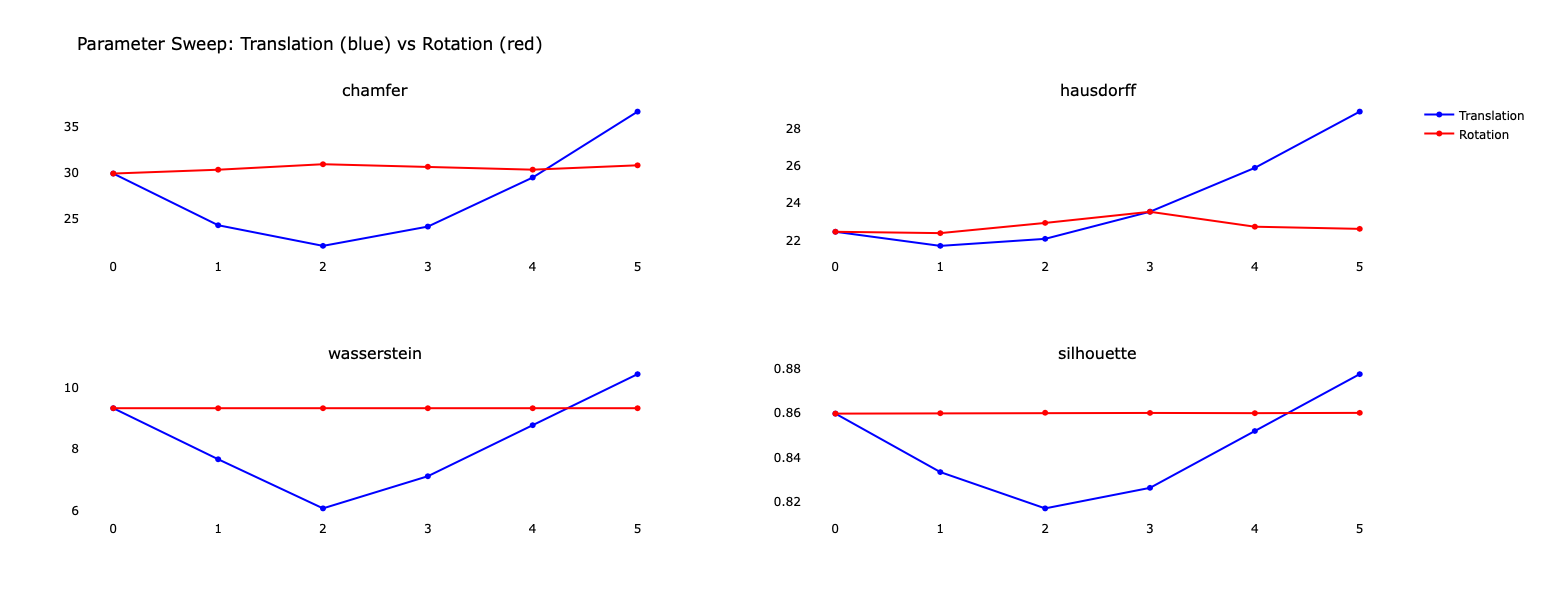

In [46]:
# Plotting sweep results
import plotly.graph_objects as go
from plotly.subplots import make_subplots

metrics = ['chamfer', 'hausdorff', 'wasserstein', 'silhouette']
steps = list(range(6))

fig = make_subplots(rows=2, cols=2, subplot_titles=metrics)

positions = [(1,1), (1,2), (2,1), (2,2)]

for metric, pos in zip(metrics, positions):
    t_vals = [r[metric] for r in translation_results]
    r_vals = [r[metric] for r in rotation_results]
    
    fig.add_trace(go.Scatter(x=steps, y=t_vals, name=f'Translation', 
                             line=dict(color='blue'), showlegend=(metric=='chamfer')),
                  row=pos[0], col=pos[1])
    fig.add_trace(go.Scatter(x=steps, y=r_vals, name=f'Rotation',
                             line=dict(color='red'), showlegend=(metric=='chamfer')),
                  row=pos[0], col=pos[1])

fig.update_layout(
    title='Parameter Sweep: Translation (blue) vs Rotation (red)',
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='black'),
    height=600
)
fig.show()

#### Translation Findings
- All 4 metrics produced a U-shaped curve across translation steps
- Metrics decreased as B moved toward A, reached a minimum at step 2, then increased as B moved past A
- This confirms all 4 metrics are sensitive to translational shifts between clusters
- Wasserstein and Silhouette showed the clearest and most proportional response to translation
- Chamfer and Hausdorff also responded but with slightly less smooth curves

#### Rotation Findings
- Wasserstein was completely flat across all 5 rotation steps, showing zero sensitivity to rotation
- Silhouette was also nearly flat, with negligible change across all rotation steps
- Chamfer showed very slight fluctuation but was largely insensitive to rotation
- Hausdorff was the most sensitive to rotation out of the four, showing visible fluctuation across steps
- If two clusters rotate relative to each other, Wasserstein and Silhouette will not detect it

| Metric | Translation | Rotation |
|---|---|---|
| Chamfer | Sensitive | Almost blind |
| Hausdorff | Sensitive | Slightly sensitive |
| Wasserstein | Sensitive | Completely blind |
| Silhouette | Sensitive | Completely blind |

#### Takeaway
- No single metric captures all types of structural differences between point clouds
- Hausdorff is the only metric that picks up rotational change, making it useful when orientation matters
- Wasserstein and Silhouette are reliable for detecting positional shifts but miss shape-level transformations
- Using all 4 metrics together gives a more complete picture than any one metric alone

<h3>Step 4 - DBSCAN on synthetic data</h3>

In [49]:
# Seperate synthetic copies
n_copies = 5
synthetic_copies = []

np.random.seed(42)  # for reproducibility
for i in range(n_copies):
    noise = np.random.normal(0, 0.5, points.shape)
    synthetic_copies.append(points + noise)

print(f"Number of synthetic plots: {len(synthetic_copies)}")
print(f"Points per plot: {len(synthetic_copies[0])}")

Number of synthetic plots: 5
Points per plot: 152


In [50]:
# Run DBSCAN on each synthetic copy
synthetic_labels = []

for i, syn_cloud in enumerate(synthetic_copies):
    db = DBSCAN(eps=10, min_samples=3)
    lab = db.fit_predict(syn_cloud)
    synthetic_labels.append(lab)
    
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_outliers = list(lab).count(-1)
    
    print(f"\nSynthetic Copy {i+1}:")
    print(f"  Clusters: {n_clusters} | Outliers: {n_outliers}")
    for label in sorted(set(lab)):
        mask = lab == label
        centroid = syn_cloud[mask].mean(axis=0)
        if label == -1:
            print(f"  Outliers: {mask.sum()} points")
        else:
            print(f"  Cluster {label}: {mask.sum()} points | centroid: PC1={centroid[0]:.2f}, PC2={centroid[1]:.2f}, PC3={centroid[2]:.2f}")


Synthetic Copy 1:
  Clusters: 5 | Outliers: 3
  Outliers: 3 points
  Cluster 0: 117 points | centroid: PC1=5.56, PC2=0.94, PC3=0.67
  Cluster 1: 10 points | centroid: PC1=-5.23, PC2=-8.06, PC3=-7.83
  Cluster 2: 4 points | centroid: PC1=-14.98, PC2=-1.21, PC3=-17.24
  Cluster 3: 9 points | centroid: PC1=-35.08, PC2=8.37, PC3=4.28
  Cluster 4: 9 points | centroid: PC1=-17.13, PC2=-13.50, PC3=7.85

Synthetic Copy 2:
  Clusters: 5 | Outliers: 3
  Outliers: 3 points
  Cluster 0: 117 points | centroid: PC1=5.54, PC2=0.97, PC3=0.70
  Cluster 1: 10 points | centroid: PC1=-5.04, PC2=-7.93, PC3=-7.95
  Cluster 2: 4 points | centroid: PC1=-15.51, PC2=-1.25, PC3=-17.36
  Cluster 3: 9 points | centroid: PC1=-34.81, PC2=8.71, PC3=3.81
  Cluster 4: 9 points | centroid: PC1=-17.22, PC2=-13.45, PC3=7.70

Synthetic Copy 3:
  Clusters: 5 | Outliers: 3
  Outliers: 3 points
  Cluster 0: 117 points | centroid: PC1=5.55, PC2=0.97, PC3=0.64
  Cluster 1: 10 points | centroid: PC1=-5.35, PC2=-7.80, PC3=-7.54


In [51]:
# Parameter sweep on all synthetic copies
syn_translation_results = []
syn_rotation_results = []

for i, (syn_cloud, lab) in enumerate(zip(synthetic_copies, synthetic_labels)):
    A_syn = syn_cloud[lab == 0]
    B_syn = syn_cloud[lab == 1]
    
    t_steps = translate_cluster(B_syn, direction=np.array([1, 0, 0]), step_size=5, n_steps=5)
    r_steps = rotate_cluster(B_syn, axis=np.array([0, 0, 1]), angle_deg=45, n_steps=5)
    
    t_results = [compute_metrics(A_syn, B_step) for B_step in t_steps]
    r_results = [compute_metrics(A_syn, B_step) for B_step in r_steps]
    
    syn_translation_results.append(t_results)
    syn_rotation_results.append(r_results)
    
    print(f"Synthetic Copy {i+1} done")

Synthetic Copy 1 done
Synthetic Copy 2 done
Synthetic Copy 3 done
Synthetic Copy 4 done
Synthetic Copy 5 done


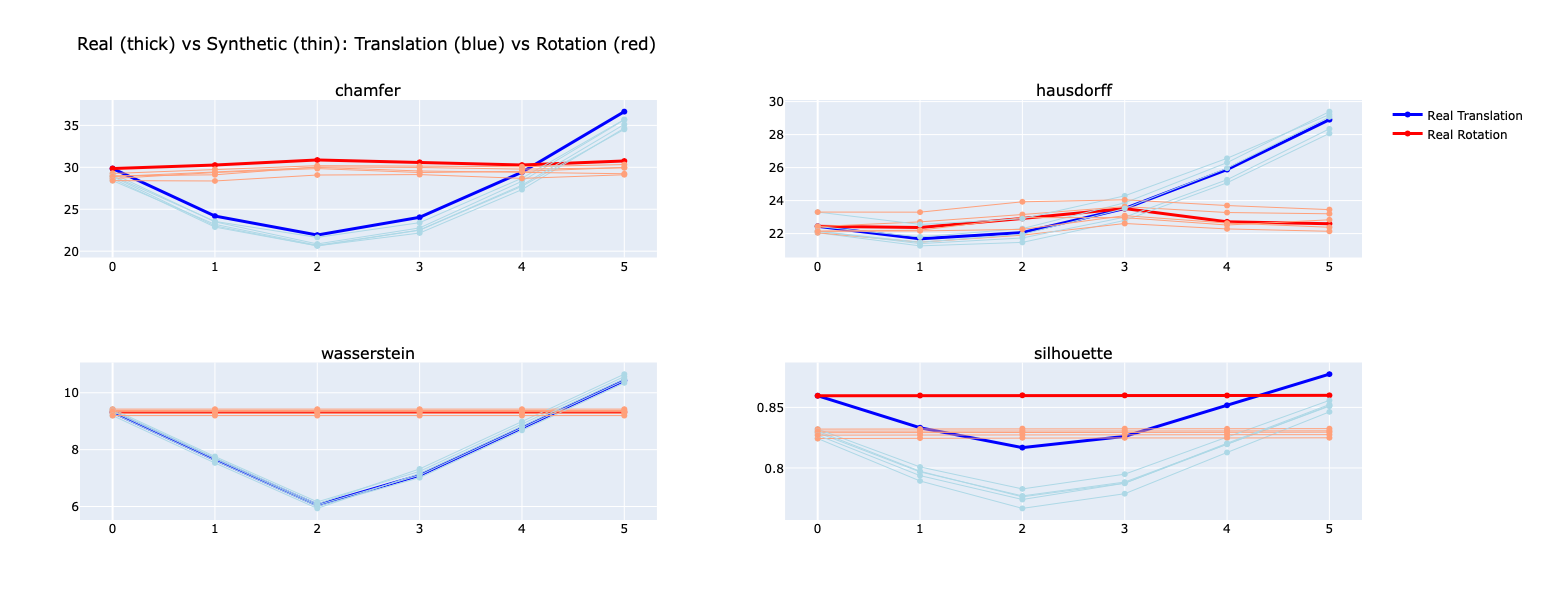

In [52]:
# Compare real vs synthetic sweep
fig = make_subplots(rows=2, cols=2, subplot_titles=metrics)
steps = list(range(6))
positions = [(1,1), (1,2), (2,1), (2,2)]

for metric, pos in zip(metrics, positions):
    # Real data lines
    t_real = [r[metric] for r in translation_results]
    r_real = [r[metric] for r in rotation_results]
    
    fig.add_trace(go.Scatter(x=steps, y=t_real, name='Real Translation',
                             line=dict(color='blue', width=3),
                             showlegend=(metric=='chamfer')),
                  row=pos[0], col=pos[1])
    fig.add_trace(go.Scatter(x=steps, y=r_real, name='Real Rotation',
                             line=dict(color='red', width=3),
                             showlegend=(metric=='chamfer')),
                  row=pos[0], col=pos[1])
    
    # Synthetic data lines (all 5 copies, thinner)
    for i in range(n_copies):
        t_syn = [r[metric] for r in syn_translation_results[i]]
        r_syn = [r[metric] for r in syn_rotation_results[i]]
        
        fig.add_trace(go.Scatter(x=steps, y=t_syn, name=f'Syn {i+1} Translation',
                                 line=dict(color='lightblue', width=1),
                                 showlegend=False),
                      row=pos[0], col=pos[1])
        fig.add_trace(go.Scatter(x=steps, y=r_syn, name=f'Syn {i+1} Rotation',
                                 line=dict(color='lightsalmon', width=1),
                                 showlegend=False),
                      row=pos[0], col=pos[1])

fig.update_layout(
    title='Real (thick) vs Synthetic (thin): Translation (blue) vs Rotation (red)',
    paper_bgcolor='white',
    font=dict(color='black'),
    height=600
)
fig.show()

#### Real vs Synthetic Parameter Sweep Comparison Findings
- All 5 synthetic copies closely tracked the real data across all 4 metrics, confirming the augmentation preserves structural properties
- Chamfer and Wasserstein showed the tightest agreement between real and synthetic
- Hausdorff showed the most variance across synthetic copies, suggesting it is more sensitive to small point-level jitter
- Silhouette dipped slightly lower in synthetic translation sweeps compared to real, reflecting slightly blurred cluster boundaries from jitter

#### Takeaway
- The metric behavior patterns observed in real data are stable and reproducible in synthetic data
- Findings from the parameter sweep are not artifacts of one specific point cloud

<h2>Conclusion: How Do SCWH Distance Metrics Detect Differences in Structured 3D Point Clouds?</h2>

**Data:** Prostate Cancer Glycan 3D Point Cloud, PCA-reduced to 3 dimensions (153 points)
**Method:** DBSCAN clustering followed by parameter sweeps (translation and rotation) on real and synthetic data

### Chamfer Distance
- Sensitive to translation, tracking the U-shaped curve cleanly as clusters moved toward and away from each other
- Nearly blind to rotation, showing only minor fluctuation across rotation steps
- Prone to underreporting structural differences due to many-to-one point matching, where multiple points can claim the same nearest neighbor
- Best used as a general proximity measure, not a shape-level descriptor

### Hausdorff Distance
- Sensitive to translation
- The only metric that showed meaningful sensitivity to rotation, making it the most geometrically complete of the four
- More variable across synthetic copies than other metrics, suggesting it is sensitive to individual point positions rather than overall distribution
- Best used when worst-case point-level differences matter, such as detecting outlier shifts or boundary changes

### Wasserstein Distance
- Sensitive to translation, with the cleanest and most proportional response
- Completely blind to rotation, producing an exactly flat line across all rotation steps
- This is because Wasserstein computes marginal distributions per axis independently, so rotating a cluster does not change the per-axis distributions enough to register
- Best used for comparing overall distributional shift between clusters

### Silhouette Score
- Sensitive to translation, clearly tracking cluster separation as B moved toward and away from A
- Nearly flat across all rotation steps, showing almost no sensitivity to rotation
- Slightly lower in synthetic data sweeps compared to real, reflecting blurred cluster boundaries from jitter
- Best used as a separation measure, not a shape or orientation measure

### Final Result
No single metric fully captures all types of structural differences between 3D point clouds. Translation is detectable by all four metrics. Rotation is only meaningfully detected by Hausdorff. Wasserstein and Silhouette are the most reliable for positional shifts but miss orientation changes entirely. For datasets like glycan point clouds where cluster orientation and shape may carry biological meaning, using all four metrics together is necessary to get a complete picture of structural differences.